# AI for photolithography process development — walkthrough

A 10-minute tour of the project, using the trained models shipped in `models/`.

1. **Physics simulator**: what a single exposure field looks like inside the model
2. **ML surrogate**: a neural network that reproduces the simulator ~2,000× faster
3. **Process window**: the dose–focus window from the simulator and from the surrogate
4. **Bayesian optimisation**: centring a recipe with few experiments
5. **CD-SEM image analysis**: a U-Net that measures CD/LER and finds defects in SEM images

All data is simulated. The simulator uses textbook lithography physics but is not calibrated to a real resist or scanner.

In [1]:
import os, sys, time, json, warnings
warnings.filterwarnings("ignore")
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")                      # run everything from the repository root
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## 1. Physics simulator

Layer: 90 nm lines at 180 nm pitch, dry ArF (193 nm), NA 0.93, σ 0.75. The chain is
aerial image (Abbe, with defocus) → acid generation → post-exposure-bake diffusion → deprotection → development threshold.
The line CD is where the deprotection profile crosses the development threshold.

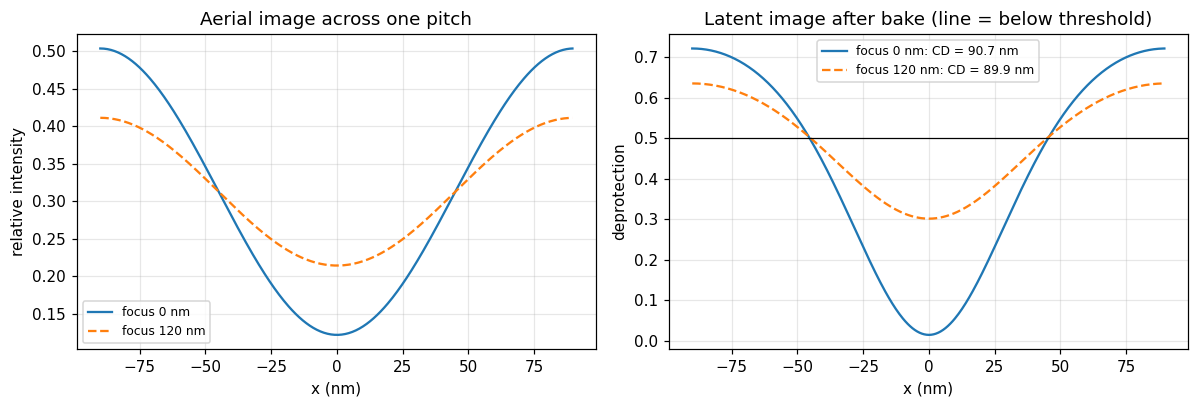

In [2]:
from litho_ai.simulator import LithoSimulator
sim = LithoSimulator()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for focus, ls in [(0, "-"), (120, "--")]:
    x, I, h = sim.profile(dose=31.5, focus=focus)
    r = sim.simulate(dose=31.5, focus=focus)
    ax[0].plot(x, I, ls, label=f"focus {focus} nm")
    ax[1].plot(x, h, ls, label=f"focus {focus} nm: CD = {r['CD']:.1f} nm")
ax[1].axhline(sim.resist.threshold, color="k", lw=0.8)
ax[0].set(xlabel="x (nm)", ylabel="relative intensity", title="Aerial image across one pitch")
ax[1].set(xlabel="x (nm)", ylabel="deprotection", title="Latent image after bake (line = below threshold)")
for a in ax: a.legend(fontsize=8)
plt.tight_layout()

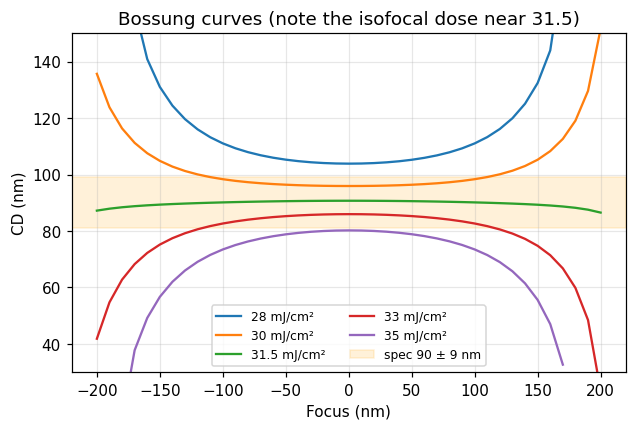

In [3]:
# Bossung curves: CD vs focus at several doses
focs = np.arange(-200, 201, 10)
fig, a = plt.subplots(figsize=(6.5, 4))
for d in [28, 30, 31.5, 33, 35]:
    cds = [sim.simulate(d, f)["CD"] for f in focs]
    a.plot(focs, np.where(np.array(cds) > 0, cds, np.nan), label=f"{d} mJ/cm²")
a.axhspan(81, 99, color="orange", alpha=0.15, label="spec 90 ± 9 nm")
a.set(ylim=(30, 150), xlabel="Focus (nm)", ylabel="CD (nm)", title="Bossung curves (note the isofocal dose near 31.5)")
a.legend(fontsize=8, ncol=2);

## 2. ML surrogate

Trained on 8,000 noisy simulated fields spanning six knobs (dose, focus, pitch, resist thickness, bake temperature and time).
The models are small MLPs saved as JSON, so the same weights run in Python and in the browser demo.

In [4]:
from litho_ai.process_window import mlp_predict
from litho_ai.generate_dataset import FEATURES

df = pd.read_csv("data/litho_dataset.csv")
test = df[(df.status_true == 0)].sample(300, random_state=1)
X = test[FEATURES].values

t0 = time.perf_counter(); pred = mlp_predict("models/mlp_cd.json", X); t_nn = time.perf_counter() - t0
t0 = time.perf_counter(); truth = [sim.simulate(**dict(zip(FEATURES, r)))["CD"] for r in X[:100]]; t_sim = (time.perf_counter() - t0) / 100 * 300

inspec = test.CD_true.between(70, 110).values
print(f"RMSE vs true CD, all printed fields : {np.sqrt(np.mean((pred - test.CD_true) ** 2)):.2f} nm")
print(f"RMSE vs true CD, 70-110 nm fields   : {np.sqrt(np.mean((pred - test.CD_true)[inspec] ** 2)):.2f} nm")
print(f"time for 300 fields: simulator {t_sim:.2f} s, neural net {t_nn * 1e3:.2f} ms")
print("(these 300 fields include training rows; the held-out numbers are in models/metrics.json)")
pd.DataFrame(json.load(open("models/metrics.json"))["cd_mlp"], index=["held-out test"]).round(2)

RMSE vs true CD, all printed fields : 3.66 nm
RMSE vs true CD, 70-110 nm fields   : 2.07 nm
time for 300 fields: simulator 0.70 s, neural net 4.46 ms
(these 300 fields include training rows; the held-out numbers are in models/metrics.json)


,rmse_vs_measured,rmse_vs_true,r2_vs_measured,rmse_vs_true_in_70_110nm
held-out test,5.79,3.89,0.97,2.56


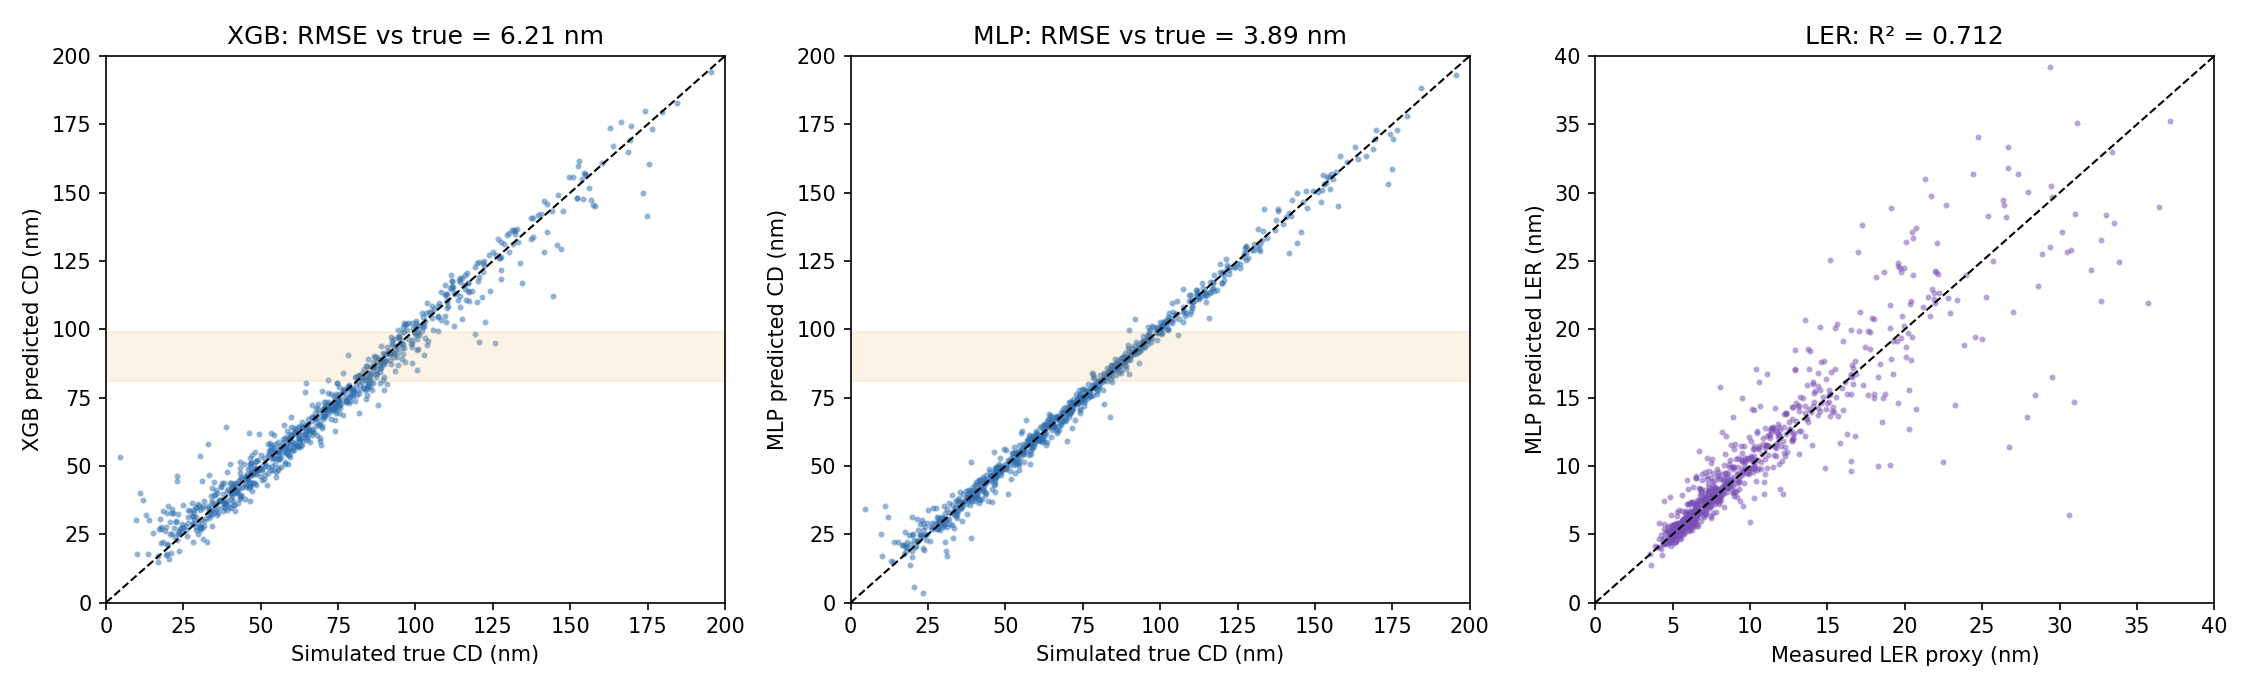

In [5]:
display(Image("figures/surrogate_parity.png", width=900))

## 3. Process window

Depth of focus (DOF) at a given exposure latitude (EL) is the standard way to size a litho process window.
Here the same exposure–defocus analysis runs on the simulator grid and on the surrogate.

In [6]:
from litho_ai.process_window import ed_curve, surrogate_grid
g = np.load("data/true_fem_grid.npz")
els, dof_true = ed_curve(g["G"], g["doses"], g["focs"])
_, dof_nn = ed_curve(surrogate_grid(g["doses"], g["focs"]), g["doses"], g["focs"])
fig, a = plt.subplots(figsize=(6, 4))
a.plot(dof_true, els * 100, label="physics simulator"); a.plot(dof_nn, els * 100, "--", label="neural-net surrogate")
a.set(xlabel="Depth of focus (nm)", ylabel="Exposure latitude (%)", title="Exposure–defocus window"); a.legend()
i5 = np.argmin(abs(els - 0.05)); print(f"DOF @ 5% EL: simulator {dof_true[i5]:.0f} nm, surrogate {dof_nn[i5]:.0f} nm")

DOF @ 5% EL: simulator 290 nm, surrogate 280 nm


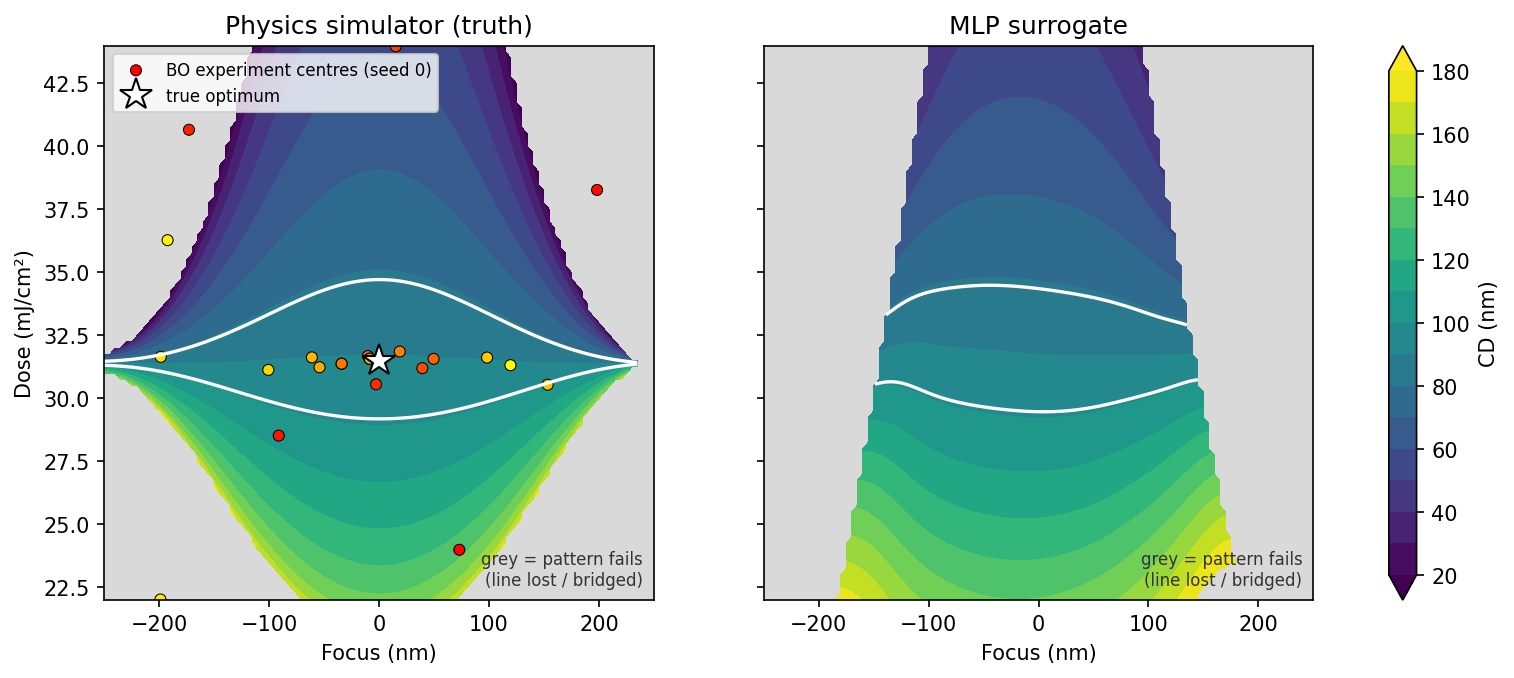

In [7]:
display(Image("figures/process_window_map.png", width=900))

## 4. Bayesian optimisation for recipe centring

Each "experiment" exposes three fields (focus −100, 0, +100 nm) at one recipe, with realistic scanner and CD-SEM noise.
**Model-based BO** fits a Gaussian process to every measured CD, computes the process window from that model, and picks
the next recipe where the model is both promising and uncertain. One run is shown below. A single run is noisy (the recommendation can get worse before it gets better),
so judge the method by the figure after it, which summarises 12 runs against a classical focus-exposure matrix (FEM).

In [8]:
from scipy.interpolate import RegularGridInterpolator
from litho_ai.bo_centring import CentringBO
from litho_ai.process_window import dof_at

interp = RegularGridInterpolator((g["doses"], g["focs"]), g["G"], bounds_error=False, fill_value=0)
true_cd = lambda d, f: float(interp([[d, f]])[0])

bo = CentringBO({"dose": (22, 44), "focus": (-200, 200)}, {"peb_temp": 110, "thickness": 120}, seed=4)
recs = bo.run(n_init=4, n_exp=15, checkpoints=[12, 21, 30, 45])
pd.DataFrame([{"fields used": n, "dose": round(r[0], 2), "focus": round(r[1]),
               "true DOF @5% EL (nm)": dof_at(true_cd, r[0], r[1])} for n, r in recs.items()]
             ).assign(**{"best possible": 304})

,fields used,dose,focus,true DOF @5% EL (nm),best possible
0,12,30.92,-2,236.0,304
1,21,30.56,5,172.0,304
2,30,30.56,5,172.0,304
3,45,31.19,-6,264.0,304


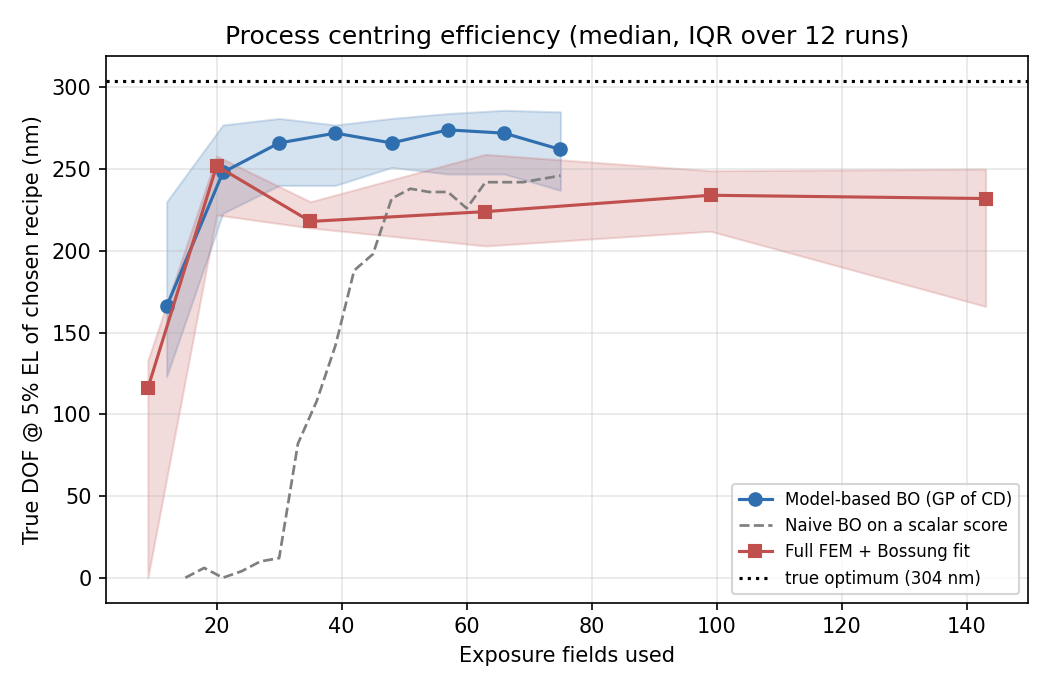

In [9]:
display(Image("figures/bo_vs_fem.png", width=700))

## 5. CD-SEM image analysis

Synthetic top-down SEM images are rendered from simulator CD and LER, with edge brightening, charging, beam blur and shot noise.
One U-Net labels every pixel as space, line, particle, bridge or break. CD and LER come from the line map row by row; defects come
from the defect pixels. The baseline is a classical line-scan algorithm (bright edge peaks, averaged scan lines).

In [10]:
import torch
from litho_ai.sem import render, SEMParams
from litho_ai.sem_unet import predict
from litho_ai.sem_eval import load_model
from litho_ai.sem_metrology import measure_unet, measure_classical, classify_unet

model = load_model()
res = json.load(open("models/sem_results.json")); off = res["cd_offset_calibration_nm"]
img, lab, meta = render(SEMParams(cd=88, pitch=180, ler=7.5, defect="bridge", frames=2), np.random.default_rng(42))
u8 = np.round(img * 255).astype(np.uint8)
prob = predict(model, u8[None])[0]
cd_u, ler_u, _ = measure_unet(prob); cd_c, ler_c, _ = measure_classical(u8 / 255)

fig, ax = plt.subplots(1, 2, figsize=(9, 4.6))
ax[0].imshow(u8, cmap="gray"); ax[0].set_title("SEM image, 2 frames (noisy fast scan)")
ax[1].imshow(u8, cmap="gray"); ax[1].imshow(np.ma.masked_equal(prob.argmax(0), 0), cmap="tab10", alpha=0.45, vmin=0, vmax=9)
ax[1].set_title(f"U-Net map: defect = {classify_unet(prob, res['area_thresholds_px'])}")
for a in ax: a.axis("off")
pd.DataFrame({"true": [meta["cd_true"], meta["ler_true"]], "U-Net": [cd_u - off["unet"], ler_u],
              "classical": [cd_c - off["classical"], ler_c]}, index=["CD (nm)", "LER 3σ (nm)"]).round(1)

,true,U-Net,classical
CD (nm),87.3,87.4,87.7
LER 3σ (nm),7.1,7.2,8.1


In [11]:
# held-out test set: 900 images, 150 per noise level
pd.DataFrame(res["by_frames"]).T[["cd_rmse_unet", "cd_rmse_classical", "ler_bias_unet", "ler_bias_classical", "defect_accuracy"]].round(2)

,cd_rmse_unet,cd_rmse_classical,ler_bias_unet,ler_bias_classical,defect_accuracy
1,0.43,6.14,0.06,11.38,0.97
2,0.30,4.90,-0.12,3.69,0.97
4,0.21,0.63,-0.17,0.47,0.99
8,0.21,1.86,-0.27,0.32,1.00
16,0.24,0.43,-0.23,-0.02,0.99
32,0.23,0.42,-0.16,-0.08,0.99


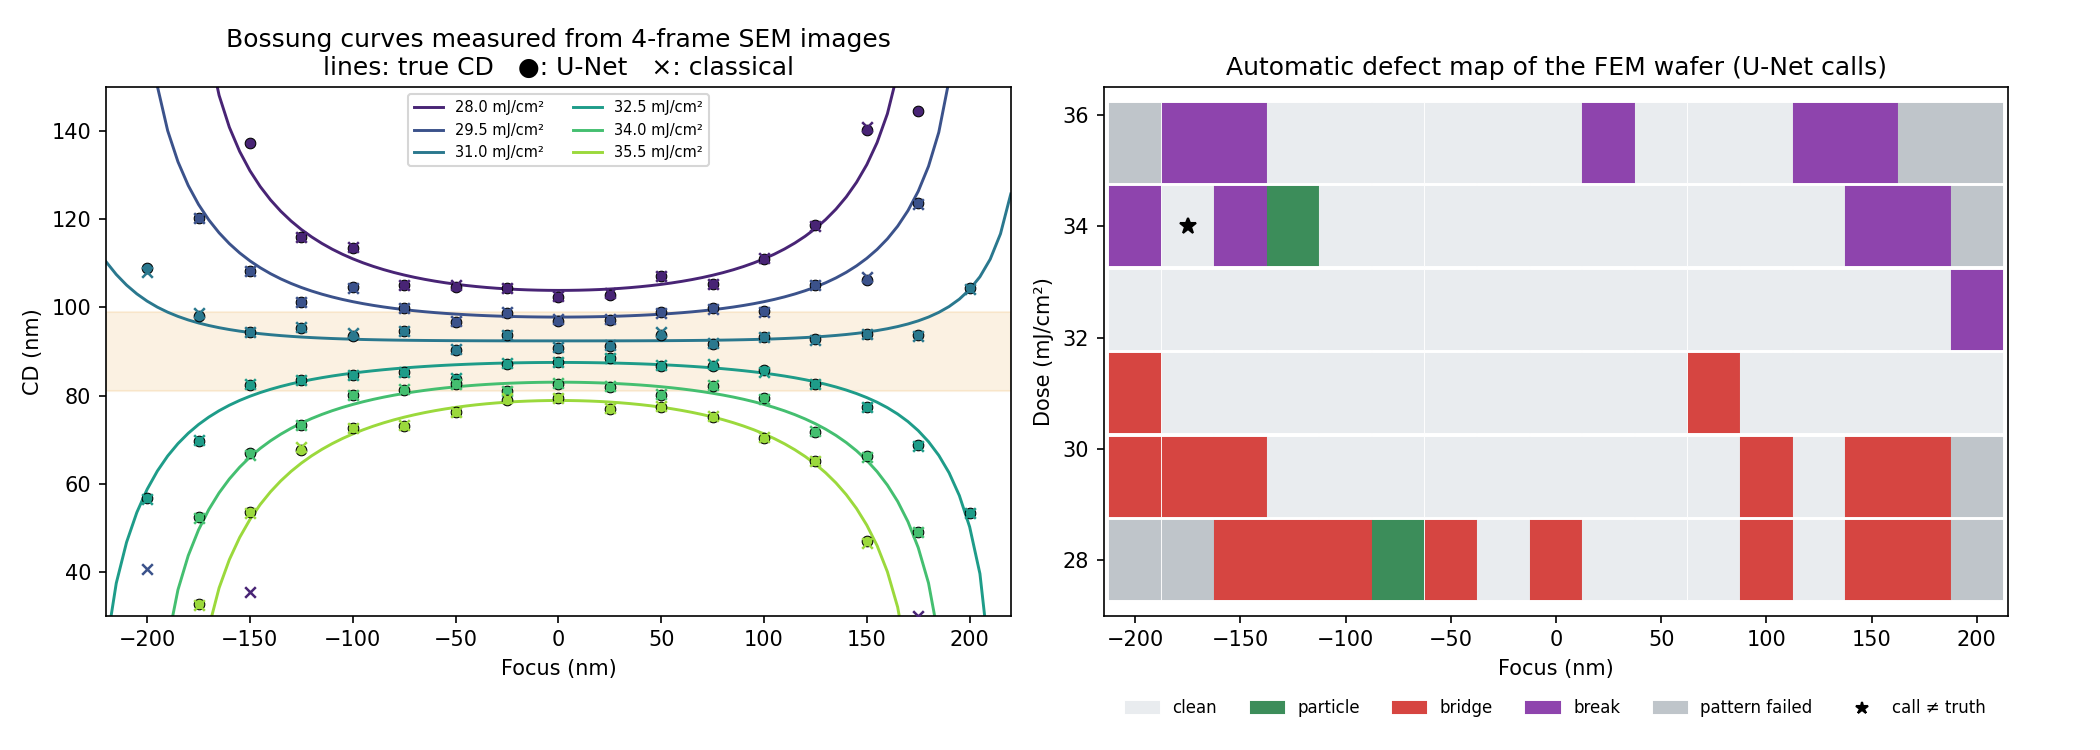

In [12]:
display(Image("figures/sem_fem_loop.png", width=900))

## Limitations and next steps

- **Synthetic data.** The next step is calibration: fit the resist model to published dose-to-size / Bossung data and test the U-Net on real SEM images.
- **1-D line/space only.** Contacts and line ends need 2-D imaging.
- **LER proxy.** Edge-gradient + shot-noise model, not a stochastic resist simulation.
- **Planned Phase 3.** Run-to-run dose control from SEM measurements (EWMA vs model-based), closing the measure → decide → correct loop.

Full results: `docs/TECHNICAL_REPORT.md`. Browser demos: `docs/index.html`.